In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

<class 'pandas.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


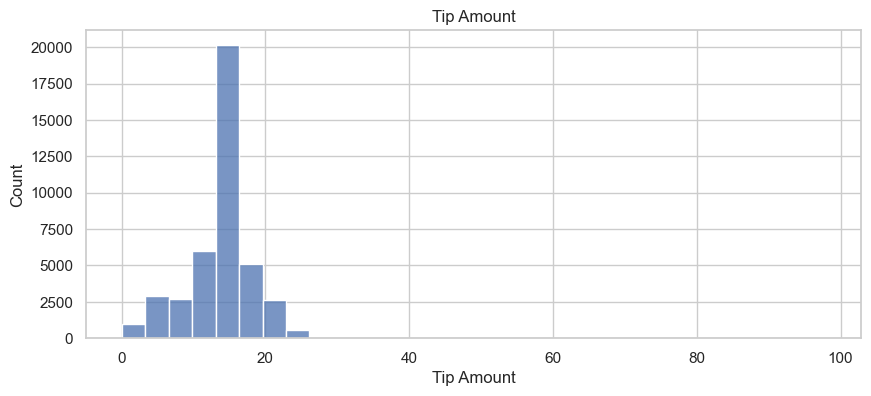

In [2]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
# taxi = pd.read_csv(...)

taxi = pd.read_csv(TAXI_URL)

# TODO: Inspect it
# - taxi.shape, taxi.head(), taxi.info()
# - taxi.describe()
# - count missing values per column: taxi.isna().sum()

taxi.shape
taxi.head()
taxi.info()
taxi.describe().T

missing = taxi.isna().sum()


# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.

plt.figure(figsize=(10, 4))
sns.histplot(taxi['tip_amount'], bins=30)
plt.title("Tip Amount")
plt.xlabel("Tip Amount")
plt.ylabel("Count")
plt.show()


The dataset has 41,202 rows and 13 columns, there were no missing values in any column but the dataset had zero and negative distnces and trips. The tip_amount distribution is right-skewed, with most trips having $0 tips and a long tail of higher tips. Because skewed and zero targets are harder for models to learn, it made performance weak later.

In [3]:
print(taxi.columns)
# import sys
# print(sys.executable)

Index(['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID',
       'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type',
       'fare_amount', 'mta_tax', 'tolls_amount', 'improvement_surcharge',
       'tip_amount'],
      dtype='str')


In [ ]:
# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.

taxi = taxi[taxi['trip_distance']> 0]
taxi = taxi[taxi['fare_amount']>0]
taxi.loc[taxi['tip_amount']<0, 'tip_amount'] = np.nan
taxi = taxi.dropna(subset = ['tip_amount'])

# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)

taxi['fare_per_mile'] = taxi['fare_amount'] / taxi['trip_distance']
taxi['total_surcharges'] = (taxi['mta_tax'] + taxi['tolls_amount'] + taxi['improvement_surcharge'])

# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).

categorical_col = ['VendorID', 'RatecodeID', 'payment_type', 'store_and_fwd_flag']
numeric_col = ['DOLocationID', 'PULocationID', 'fare_amount', 'improvement_surcharge', 'mta_tax', 
               'passenger_count', 'tolls_amount', 'trip_distance']
taxi = pd.get_dummies(taxi, columns= categorical_col, drop_first=True)

# TODO: Scale the numeric features.
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)

from sklearn.preprocessing import StandardScaler


Rows with negative distances and fare amounts were removed using filters, and negative tips were treated as errors and dropped. Two new features were created, fare_per_mile and total_surcharges. They do not use the target, so there’s no leakage. StandardScaler was applied because features were on very different scales, and models like linear regression can get biased if large-scale variables dominate.

In [6]:
# TODO: Separate features (X) and target (y = tip_amount)
x = taxi.drop(columns=['tip_amount'])
y = taxi['tip_amount']

# TODO: Split into train / validation / test (a common choice is 60/20/20).
#   from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.

from sklearn.model_selection import train_test_split
x_temp, x_test, y_temp, y_test = train_test_split(x, y, test_size=0.2, random_state= RANDOM_STATE)
x_train, x_val, y_train, y_val = train_test_split(x_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE)

# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
#   (Explain in the reasoning box why scaling must be fit on train only.)

numeric_col = [c for c in numeric_col if c in x_train.columns]

scaler = StandardScaler()
x_train[numeric_col] = scaler.fit_transform(x_train[numeric_col])
x_val[numeric_col]   = scaler.transform(x_val[numeric_col])
x_test[numeric_col]  = scaler.transform(x_test[numeric_col])

A 60/20/20 split was used train/validation/test, and the scaler was fit only on training data to avoid data leakage. The validation set is used for tuning, while the test set is kept untouched for a final unbiased evaluation.

LinearRegression Train   RMSE=4.8045  R2=0.0513
LinearRegression Val     RMSE=5.0371  R2=0.0486
LinearRegression Test    RMSE=5.0132  R2=0.0511
RandomForest    Train   RMSE=2.8288  R2=0.6711
RandomForest    Val     RMSE=5.6408  R2=-0.1930
RandomForest    Test    RMSE=5.6060  R2=-0.1866


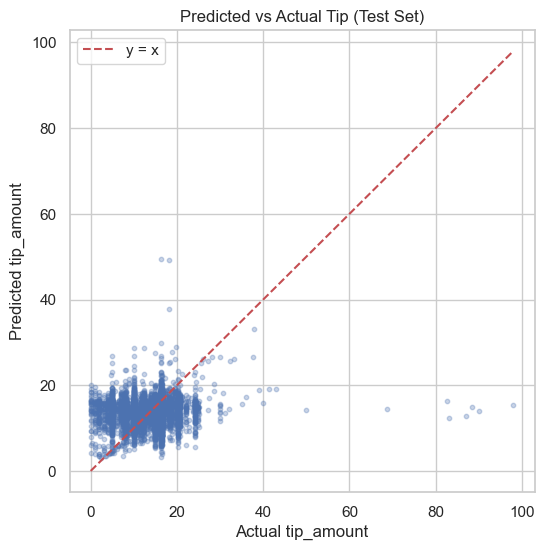

In [8]:
# TODO: Import, initialise, and train a regression model.
#   Start simple (LinearRegression), then try a more flexible model
#   (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# TODO: Predict on train, validation, and test sets.

linear_reg = LinearRegression()
linear_reg.fit(x_train, y_train)

random_forest_reg = RandomForestRegressor(n_estimators=200, random_state= RANDOM_STATE)
random_forest_reg.fit(x_train, y_train)


# TODO: Report RMSE and R^2 for ALL THREE sets.
#   from sklearn.metrics import mean_squared_error, r2_score
#   (RMSE = mean_squared_error(y_true, y_pred) ** 0.5)

from sklearn.metrics import mean_squared_error, r2_score

def evaluate_regressor(model, name):
    for split_name, x_split, y_split in [
        ('Train', x_train, y_train), ('Val', x_val, y_val), ('Test', x_test, y_test)
    ]:
        preds = model.predict(x_split)
        rmse = mean_squared_error(y_split, preds) ** 0.5
        r2 = r2_score(y_split, preds)
        print(f"{name:15s} {split_name:6s}  RMSE={rmse:.4f}  R2={r2:.4f}")

evaluate_regressor(linear_reg, "LinearRegression")
evaluate_regressor(random_forest_reg, "RandomForest")


# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line).
best_model = random_forest_reg  
preds_test = best_model.predict(x_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, preds_test, alpha=0.3, s=10)
lims = [0, max(y_test.max(), preds_test.max())]
plt.plot(lims, lims, 'r--', label='y = x')
plt.xlabel('Actual tip_amount')
plt.ylabel('Predicted tip_amount')
plt.title('Predicted vs Actual Tip (Test Set)')
plt.legend()
plt.show()


Random Forest performed very well on training (R² ≈ 0.67) but performed badly on validation and test, showing overfitting. Linear Regression was weak but consistent across all splits, meaning it underfits rather than overfits. So in this case, the simpler model actually generalised better than the more flexible one. The main fix for Random Forest would be limiting complexity (like max_depth or min_samples_leaf) to reduce overfitting.

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

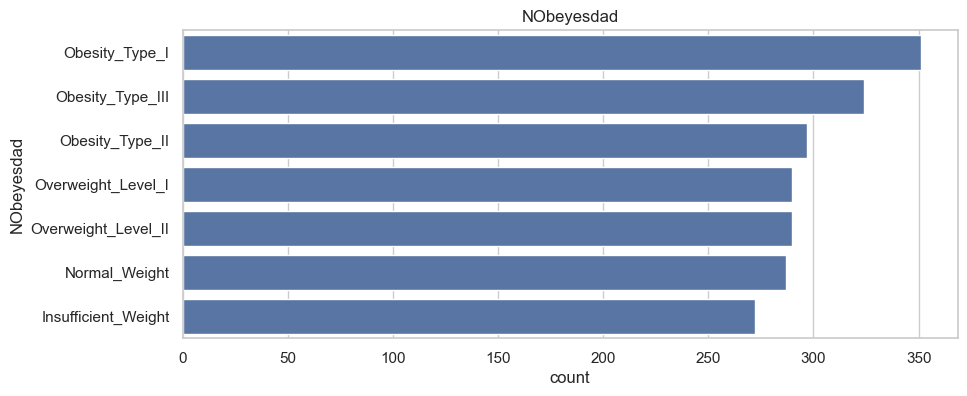

In [9]:
# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`
obesity = pd.read_csv(OBESITY_URL)

# TODO: Inspect shape, head, info, describe, and missing values.
obesity.shape
obesity.head()
obesity.info()
obesity.info()
obesity.describe().T

missing = obesity.isna().sum()

# TODO: Show the class distribution of `NObeyesdad`
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?

plt.figure(figsize=(10, 4))
sns.countplot(data=obesity, y='NObeyesdad', order=obesity['NObeyesdad'].value_counts().index)
plt.title('NObeyesdad')
plt.show()


The dataset has 2,111 rows and 17 columns, split into numeric and categorical features, and there were no missing values. The target classes are fairly balanced, so no single class dominates. This balance is important because accuracy alone can be misleading, macro-F1 is used to make sure all classes are treated equally.

In [10]:
# TODO: Encode categorical columns.
#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
#   - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS) -> choose an encoding
#     and justify it (LabelEncoder / OrdinalEncoder / pd.get_dummies / OneHotEncoder).

binary_col = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for col in binary_col:
    obesity[col] = obesity[col].map({'yes': 1, 'no': 0})

freq_order = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
obesity['CAEC'] = obesity['CAEC'].map(freq_order)
obesity['CALC'] = obesity['CALC'].map(freq_order)

obesity = pd.get_dummies(obesity, columns=['Gender', 'MTRANS'], drop_first=True)

# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
#   Discuss whether including BMI makes the task "too easy" / leaks the target.

obesity['BMI'] = obesity['Weight'] / (obesity['Height'] ** 2)

# TODO: Encode the target `NObeyesdad` into integer class labels
#   from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()

# TODO: Scale the numeric features (fit on TRAIN only, in Part 2.3).
from sklearn.preprocessing import StandardScaler


Binary variables were encoded as 0/1, ordinal features were mapped to ordered values, and categorical variables like gender and transport were one-hot encoded. BMI was engineered from weight and height. It does not leak the target directly, but it does make the task easier since BMI is closely tied to how obesity categories are defined. StandardScaler was applied to keep all numeric features on the same scale.

In [11]:
# TODO: Separate X (features) and y (encoded NObeyesdad).

x = obesity.drop(columns=['NObeyesdad'])
y = target_encoder.fit_transform(obesity['NObeyesdad'])

# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.25, random_state=RANDOM_STATE, stratify=y_train)

# TODO: Fit the scaler on the training set only, then transform train / val / test.
numeric_col = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI']
numeric_col = [c for c in numeric_col if c in x_train.columns]

scaler = StandardScaler()
x_train[numeric_col] = scaler.fit_transform(x_train[numeric_col])
x_val[numeric_col]   = scaler.transform(x_val[numeric_col])
x_test[numeric_col]  = scaler.transform(x_test[numeric_col])

60/20/20 split was used with stratification to preserve class proportions across all sets. This is important because without it, some classes could be underrepresented or missing in validation/test, making evaluation unreliable.

LogisticRegression   Train   Acc=0.9281  MacroF1=0.9258
LogisticRegression   Val     Acc=0.8839  MacroF1=0.8779
LogisticRegression   Test    Acc=0.9007  MacroF1=0.8972
RandomForest         Train   Acc=1.0000  MacroF1=1.0000
RandomForest         Val     Acc=0.9929  MacroF1=0.9925
RandomForest         Test    Acc=0.9929  MacroF1=0.9926
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.98      0.98        54
      Normal_Weight       0.98      0.98      0.98        58
     Obesity_Type_I       1.00      1.00      1.00        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       1.00      1.00      1.00        58
Overweight_Level_II       1.00      1.00      1.00        58

           accuracy                           0.99       423
          macro avg       0.99      0.99      0.99       423
       weighted avg       0.99      0.99      0.99  

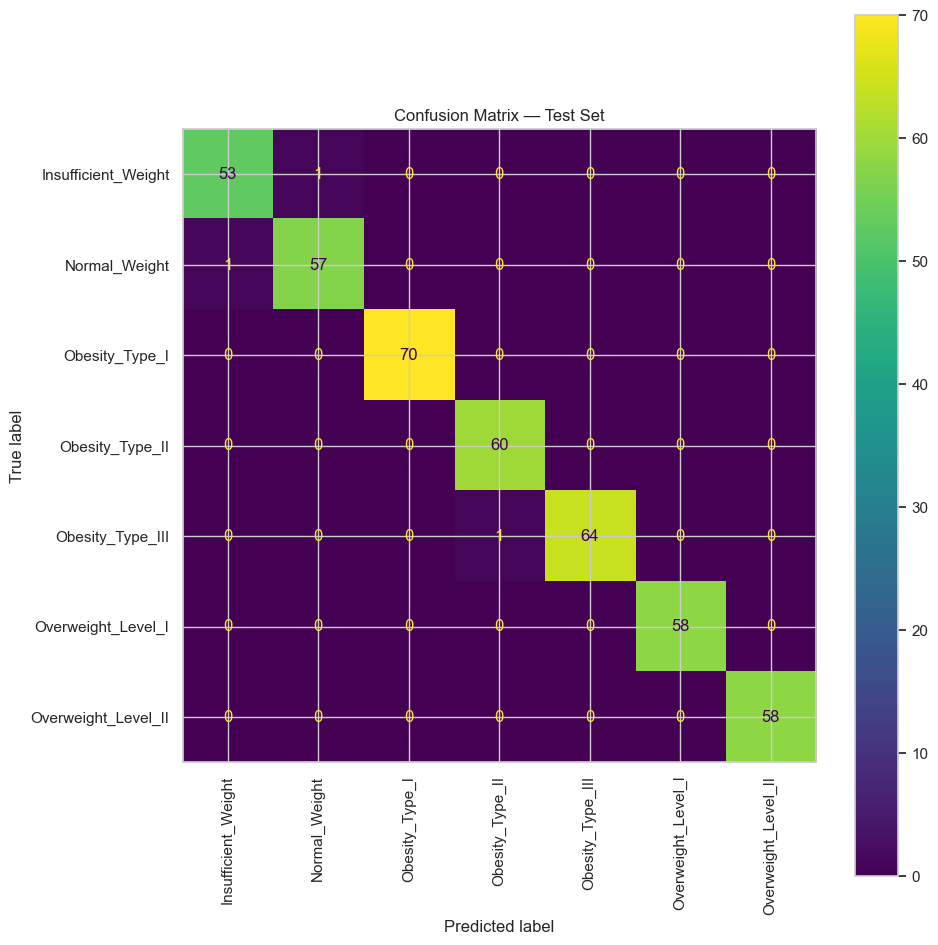

In [12]:
# TODO: Import, initialise, and train a classifier
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# TODO: Predict on train, validation, and test.
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(x_train, y_train)

rf_clf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf_clf.fit(x_train, y_train)


# TODO: Report accuracy AND macro-F1 for ALL THREE sets
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

def evaluate_classifier(model, name):
    for split_name, x_split, y_split in [
        ('Train', x_train, y_train), ('Val', x_val, y_val), ('Test', x_test, y_test)
    ]:
        preds = model.predict(x_split)
        acc = accuracy_score(y_split, preds)
        f1 = f1_score(y_split, preds, average='macro')
        print(f"{name:20s} {split_name:6s}  Acc={acc:.4f}  MacroF1={f1:.4f}")

evaluate_classifier(log_reg, "LogisticRegression")
evaluate_classifier(rf_clf, "RandomForest")

# TODO: Show a confusion matrix for the test set
#   from sklearn.metrics import ConfusionMatrixDisplay
#   Which classes are most often confused?

best_clf = rf_clf  
preds_test_o = best_clf.predict(x_test)
print(classification_report(y_test, preds_test_o, target_names=target_encoder.classes_))

fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test, preds_test_o, display_labels=target_encoder.classes_,
    xticks_rotation=90, ax=ax
)
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

Random Forest performed extremely well, with near perfect training, validation, and test scores. Most errors happen between neighbouring classes, which makes sense because those categories are close in BMI/weight space.

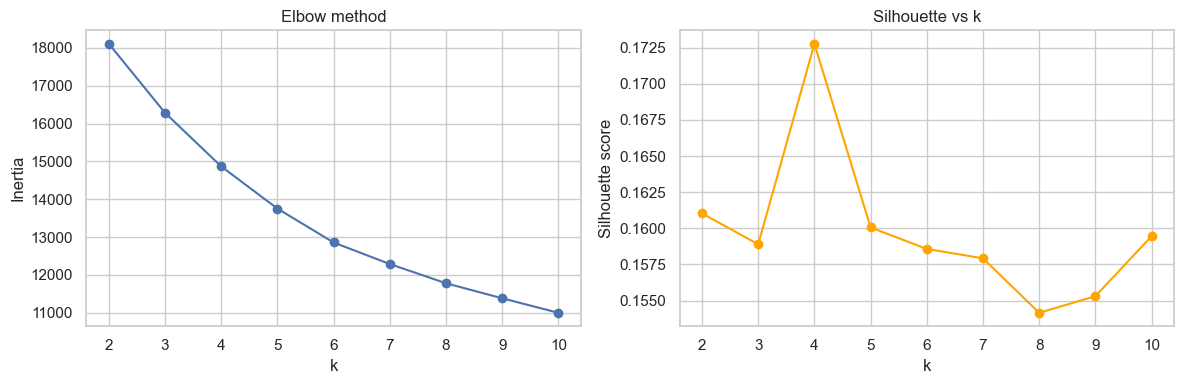

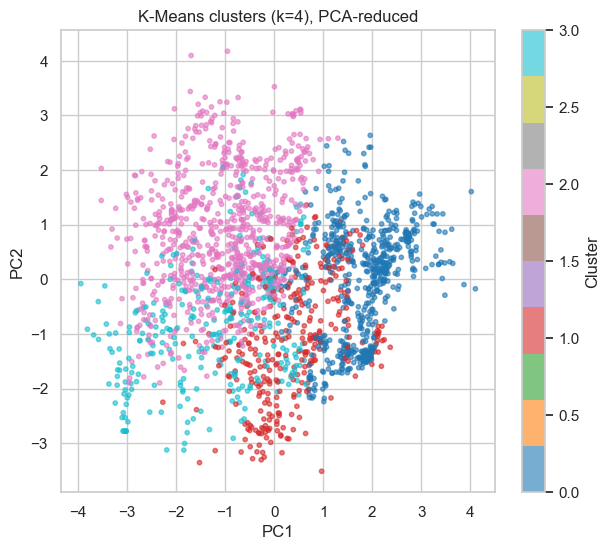

col_0,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
row_0,,,,,,,
0,0,0,90,208,324,0,4
1,2,16,99,60,0,55,101
2,218,219,99,1,0,155,138
3,52,52,63,28,0,80,47


In [17]:
# TODO: Use ONLY the scaled obesity features (no target) for clustering.

x_cluster = pd.concat([x_train, x_val, x_test], ignore_index=True)

# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
#   from sklearn.cluster import KMeans
#   from sklearn.metrics import silhouette_score
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias, silhouettes = [], []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(x_cluster)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(x_cluster, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia'); axes[0].set_title('Elbow method')

axes[1].plot(list(k_range), silhouettes, marker='o', color='orange')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette score'); axes[1].set_title('Silhouette vs k')
plt.tight_layout()
plt.show()


# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.

chosen_k =   4
kmeans_final = KMeans(n_clusters=chosen_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans_final.fit_predict(x_cluster)

# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.

from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(x_cluster)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_labels, cmap='tab10', alpha=0.6, s=10)
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title(f'K-Means clusters (k={chosen_k}), PCA-reduced')
plt.colorbar(scatter, label='Cluster')
plt.show()

y_full = pd.concat([
    pd.Series(y_train), pd.Series(y_val), pd.Series(y_test)
]).reset_index(drop=True)
true_labels_full = target_encoder.inverse_transform(y_full)

crosstab = pd.crosstab(cluster_labels, true_labels_full)
crosstab

In [18]:
# TODO: How well do the clusters line up with the TRUE obesity levels?
#   Build a crosstab of cluster label vs the real NObeyesdad category:
#   pd.crosstab(cluster_labels, obesity['NObeyesdad'])
#   Do some clusters map cleanly onto specific obesity levels?

y_full = pd.concat([
    pd.Series(y_train), pd.Series(y_val), pd.Series(y_test)
]).reset_index(drop=True)
true_labels_full = target_encoder.inverse_transform(y_full)

crosstab = pd.crosstab(cluster_labels, true_labels_full)
crosstab

col_0,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
row_0,,,,,,,
0,0,0,90,208,324,0,4
1,2,16,99,60,0,55,101
2,218,219,99,1,0,155,138
3,52,52,63,28,0,80,47


k = 4 was chosen because the elbow plot flattens around 4–5, and the silhouette score peaks at 4, so both metrics support it. The clusters don’t match the 7 obesity labels exactly, but instead group people into broader severity levels: very high obesity, low/normal weight, and mixed middle groups. So K-Means is capturing general risk bands rather than fine categories. This makes k=4 useful for rough health risk grouping, while the supervised model is better for precise classification.

1. Supervised vs Unsupervised

Supervised learning predicts known answers, unsupervised learning finds hidden patterns without knowing the answers. The classifier learnt using labeled data, meaning it mapped features directly to the 7 obesity categories and can predict the exact class for new data. K-Means however, did not use any labels, it just grouped people based on similarity in the features. Because of that, it can reveal hidden patterns like grouping by activity level instead of official obesity labels, but it doesn’t know what each cluster actually means until you match it with the real labels.

2. Regression vs Classification 

For regression, I measured performance by using how far predictions are from the real values (RMSE) and how well the model explains variation in the data (R²), so small errors still matter. For classification (obesity levels), it’s strictly right or wrong, so you use accuracy and macro-F1, especially because macro-F1 handles imbalance across the 7 classes better than accuracy alone.

3. Overfitting
R² drops from about 0.67 on training to negative on validation and test, meaning it performs worse than predicting the mean. This shows it memorised training patterns that do not generalise. For obesity, the Random Forest hits perfect training accuracy (1.00) but still performs almost equally well on validation and test (~0.99), so there is no serious overfitting and it generalises well.
